<a href="https://colab.research.google.com/github/kosar-am/day-night-road-cyclegan/blob/main/notebooks/02_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day-to-Night Road Scene Translation using CycleGAN

## Data Preparation

In this notebook, we will:

- Load the BDD100K dataset
- Read and organize image metadata
- Create daytime and nighttime image lists
- Split the dataset into training and validation sets
- Define image transformations
- Build custom PyTorch datasets
- Create efficient DataLoaders
- Visualize sample batches before training


# Import Libraries

In [27]:
import json
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import random
import pickle

from google.colab import drive



# Load Dataset

In [9]:
# Download the BDD100K dataset from KaggleHub
dataset_path = kagglehub.dataset_download("alvaromalfaro/bdd100k")

# Convert the downloaded path to a Path object
dataset_path = Path(dataset_path) / "bdd100k"

# Define the training image and label directories
train_images_path = dataset_path / "images" / "100k" / "train"
train_labels_path = dataset_path / "labels" / "train"

# Display the main dataset paths
print(f"Dataset path: {dataset_path}")
print(f"Training images path: {train_images_path}")
print(f"Training labels path: {train_labels_path}")

Using Colab cache for faster access to the 'bdd100k' dataset.
Dataset path: /kaggle/input/bdd100k/bdd100k
Training images path: /kaggle/input/bdd100k/bdd100k/images/100k/train
Training labels path: /kaggle/input/bdd100k/bdd100k/labels/train


# Create Day and Night Image Lists

In [10]:
# Collect all training label files
label_files = sorted(train_labels_path.glob("*.json"))

# Create empty lists for daytime and nighttime image paths
day_image_paths = []
night_image_paths = []

# Read each label file and separate images by time of day
for label_file in label_files:
    with open(label_file, "r") as file:
        label_data = json.load(file)

    time_of_day = label_data["attributes"]["timeofday"]
    image_name = label_data["name"]

    # Add the JPEG extension when it is missing
    if not image_name.lower().endswith((".jpg", ".jpeg")):
        image_name += ".jpg"

    image_path = train_images_path / image_name

    if time_of_day == "daytime":
        day_image_paths.append(image_path)

    elif time_of_day == "night":
        night_image_paths.append(image_path)

In [11]:
# Display the number of daytime and nighttime images
print(f"Daytime images: {len(day_image_paths)}")
print(f"Night images  : {len(night_image_paths)}")

Daytime images: 36800
Night images  : 28028


# Validate Image Paths

In [12]:
# Validate the image paths
missing_day_images = [
    image_path for image_path in day_image_paths
    if not image_path.exists()
]

missing_night_images = [
    image_path for image_path in night_image_paths
    if not image_path.exists()
]

print(f"Missing daytime images: {len(missing_day_images)}")
print(f"Missing night images  : {len(missing_night_images)}")

Missing daytime images: 0
Missing night images  : 0


In [13]:
print("JSON image name:", label_data["name"])
print("Actual image file:", next(train_images_path.glob("*.jpg")).name)

JSON image name: fe189115-8dabb5b1
Actual image file: 20679230-49a34f75.jpg


## Analysis

All daytime and nighttime image paths were successfully validated. No missing image files were found in either domain.

# Visualize Day and Night Samples

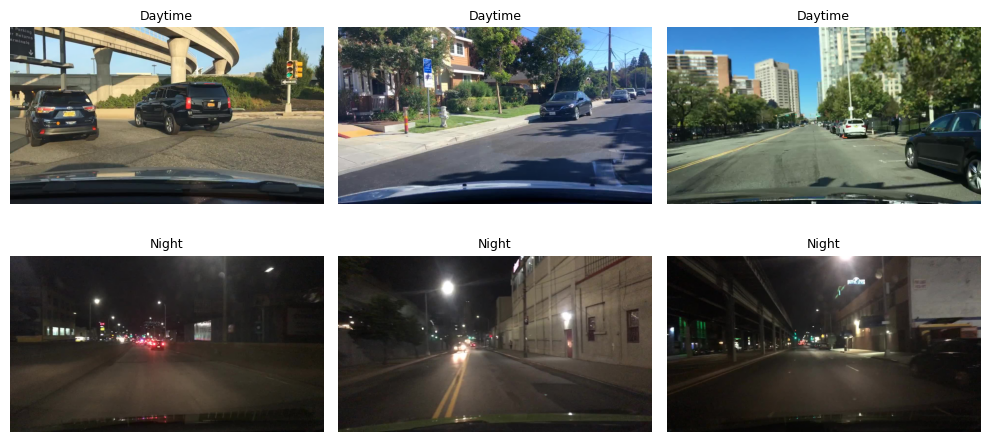

In [14]:
# Select three sample images from each domain
day_samples = day_image_paths[:3]
night_samples = night_image_paths[:3]

# Display daytime and nighttime samples
plt.figure(figsize=(10, 5))

for i, image_path in enumerate(day_samples):
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title("Daytime", fontsize=9)
    plt.axis("off")

for i, image_path in enumerate(night_samples):
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 4)
    plt.imshow(image)
    plt.title("Night", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Shuffle Image Lists

In [16]:


# Set a random seed for reproducibility
random.seed(42)

# Shuffle image paths
random.shuffle(day_image_paths)
random.shuffle(night_image_paths)

# Train and Validation Split


In [15]:
# Set the validation ratio
validation_ratio = 0.2

# Calculate split indexes
day_split_index = int(len(day_image_paths) * (1 - validation_ratio))
night_split_index = int(len(night_image_paths) * (1 - validation_ratio))

# Split daytime image paths
day_train_images = day_image_paths[:day_split_index]
day_val_images = day_image_paths[day_split_index:]

# Split nighttime image paths
night_train_images = night_image_paths[:night_split_index]
night_val_images = night_image_paths[night_split_index:]

# Display split sizes
print(f"Day train images   : {len(day_train_images)}")
print(f"Day validation     : {len(day_val_images)}")
print(f"Night train images : {len(night_train_images)}")
print(f"Night validation   : {len(night_val_images)}")

Day train images   : 29440
Day validation     : 7360
Night train images : 22422
Night validation   : 5606


## Analysis

The dataset was split into **training (80%)** and **validation (20%)** sets for both domains. This split ensures that the model is trained on the majority of the data while reserving unseen images for performance evaluation during training.

# Define Image Transformations

In [18]:
# Define image transformations for CycleGAN
image_size = 256

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

# Build Custom Dataset

In [19]:
# Create a custom PyTorch dataset for unpaired daytime and nighttime images
class DayNightDataset(Dataset):
    def __init__(
        self,
        day_image_paths,
        night_image_paths,
        transform=None
    ):
        self.day_image_paths = day_image_paths
        self.night_image_paths = night_image_paths
        self.transform = transform

    def __len__(self):
        return max(
            len(self.day_image_paths),
            len(self.night_image_paths)
        )

    def __getitem__(self, index):
        day_path = self.day_image_paths[
            index % len(self.day_image_paths)
        ]

        night_path = self.night_image_paths[
            index % len(self.night_image_paths)
        ]

        day_image = Image.open(day_path).convert("RGB")
        night_image = Image.open(night_path).convert("RGB")

        if self.transform:
            day_image = self.transform(day_image)
            night_image = self.transform(night_image)

        return {
            "day": day_image,
            "night": night_image
        }

# Test Custom Dataset

In [20]:
# Create the training dataset
train_dataset = DayNightDataset(
    day_train_images,
    night_train_images,
    transform=train_transform,
)

# Display the dataset size
print(f"Training samples: {len(train_dataset)}")

Training samples: 29440


In [21]:
# Get one sample from the dataset
sample = train_dataset[0]

print(sample.keys())
print(sample["day"].shape)
print(sample["night"].shape)

dict_keys(['day', 'night'])
torch.Size([3, 256, 256])
torch.Size([3, 256, 256])


# Create Datasets

In [22]:
# Create training and validation datasets
train_dataset = DayNightDataset(
    day_train_images,
    night_train_images,
    transform=train_transform,
)

val_dataset = DayNightDataset(
    day_val_images,
    night_val_images,
    transform=val_transform,
)

# Display dataset sizes
print(f"Training samples  : {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples  : 29440
Validation samples: 7360


# Create DataLoaders

In [23]:
# Define the batch size
batch_size = 8

# Create the training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

# Create the validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
)

print(f"Training batches  : {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches  : 3680
Validation batches: 920


# Test DataLoaders

In [24]:
# Get one batch from the training DataLoader
batch = next(iter(train_loader))

day_batch = batch["day"]
night_batch = batch["night"]

print(f"Day batch shape  : {day_batch.shape}")
print(f"Night batch shape: {night_batch.shape}")

Day batch shape  : torch.Size([8, 3, 256, 256])
Night batch shape: torch.Size([8, 3, 256, 256])


# Visualize Sample Batches

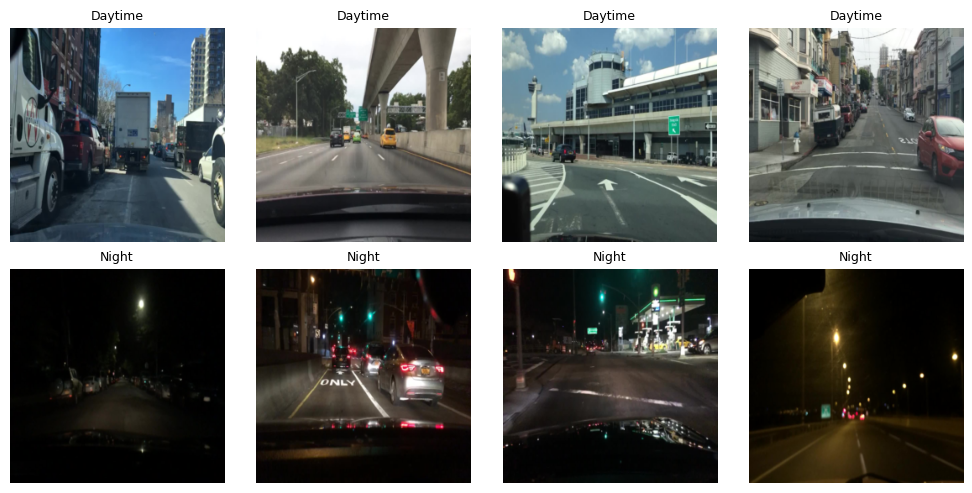

In [25]:
# Convert normalized tensors back to displayable images
def denormalize(image_tensor):
    return image_tensor * 0.5 + 0.5


# Display four daytime and four nighttime images
plt.figure(figsize=(10, 5))

for i in range(4):
    day_image = denormalize(day_batch[i]).permute(1, 2, 0)

    plt.subplot(2, 4, i + 1)
    plt.imshow(day_image)
    plt.title("Daytime", fontsize=9)
    plt.axis("off")

for i in range(4):
    night_image = denormalize(night_batch[i]).permute(1, 2, 0)

    plt.subplot(2, 4, i + 5)
    plt.imshow(night_image)
    plt.title("Night", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Preparation Pipeline

```text
BDD100K Dataset
       │
       ▼
Load Dataset
• Download dataset
• Define image and label paths
       │
       ▼
Create Day/Night Image Lists
• Read JSON annotations
• Separate daytime and nighttime images
• Exclude dawn/dusk and undefined images
       │
       ▼
Validate Image Paths
• Verify image paths
• Check for missing files
• Fix filename extensions (.jpg)
       │
       ▼
Shuffle Image Lists
• Randomize image order
• Ensure reproducible results (seed = 42)
       │
       ▼
Train / Validation Split
• 80% Training
• 20% Validation
• Split both domains independently
       │
       ▼
Define Image Transformations
• Resize images to 256×256
• Apply random horizontal flip (training only)
• Convert images to tensors
• Normalize pixel values
       │
       ▼
Build Custom Dataset
• Read images on demand
• Apply transformations
• Return paired day/night samples
       │
       ▼
Create DataLoaders
• Create mini-batches
• Shuffle training batches
• Prepare validation batches
       │
       ▼
Test Dataset & DataLoaders
• Verify dataset size
• Check tensor shapes
• Visualize sample batches
       │
       ▼
Ready for CycleGAN Training
```

# Analysis

The data preparation pipeline was successfully completed.

The dataset was divided into training and validation sets, image transformations were defined, a custom PyTorch dataset was implemented, and DataLoaders were created. The final visualization confirmed that both daytime and nighttime images are correctly loaded and ready for CycleGAN training.

# Conclusion

In this notebook, the BDD100K dataset was prepared for CycleGAN training.

The completed pipeline includes:

- Day and night image separation
- Image path validation
- Dataset shuffling
- Train/validation split
- Image transformations
- Custom PyTorch dataset
- DataLoaders
- Batch visualization

The dataset is now fully prepared for building and training the CycleGAN model.

In [28]:


# Mount Google Drive
drive.mount("/content/drive")

# Directory to save processed files
save_dir = Path("/content/drive/MyDrive/My-Project/CycleGAN_Project-2026/saved")
save_dir.mkdir(parents=True, exist_ok=True)

# Save image lists
datasets = {
    "day_train_images.pkl": day_train_images,
    "day_val_images.pkl": day_val_images,
    "night_train_images.pkl": night_train_images,
    "night_val_images.pkl": night_val_images,
}

for filename, data in datasets.items():
    with open(save_dir / filename, "wb") as file:
        pickle.dump(data, file)

print("Image lists saved successfully!")

Mounted at /content/drive
Image lists saved successfully!
